<a href="https://colab.research.google.com/github/iarabertopena/ml-learning-lab/blob/main/stream__learning_multi_label.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Bibliotecas

In [ ]:
%%writefile requirements.txt
numpy
pandas
scipy
matplotlib
seaborn
capymoa
psutil
liac-arff

Overwriting requirements.txt


In [ ]:
!pip install -r requirements.txt

### Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import psutil
import time
import os

from capymoa.classifier import AdaptiveRandomForestClassifier

from capymoa.evaluation import prequential_evaluation

from capymoa.drift.detectors import ADWIN

from capymoa.stream import NumpyStream
from capymoa.stream import Schema

from IPython.utils import process
from collections import deque
from scipy.io import arff

from sklearn.metrics import (hamming_loss, f1_score)

### Datasets

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/Flags.zip"

extract_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/flags"

with zipfile.ZipFile(base_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

dataset_path = os.path.join(extract_path, "flags.arff")

print(dataset_path)

Mounted at /content/drive
/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/flags/flags.arff


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/Emotions.zip"

extract_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/emotions"

with zipfile.ZipFile(base_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

dataset_path = os.path.join(extract_path, "emotions.arff")

print(dataset_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/emotions/emotions.arff


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/Scene.zip"

extract_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/scene"

with zipfile.ZipFile(base_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

dataset_path = os.path.join(extract_path, "scene.arff")

print(dataset_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/scene/scene.arff


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/Ohsumed.zip"

extract_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/ohsumed"

with zipfile.ZipFile(base_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

dataset_path = os.path.join(extract_path, "OHSUMED-F.arff")

print(dataset_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/ohsumed/OHSUMED-F.arff


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/20NG.zip"

extract_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/20NG"

with zipfile.ZipFile(base_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

dataset_path = os.path.join(extract_path, "20NG-F.arff")

print(dataset_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/20NG/20NG-F.arff


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/SynHPGrad.arff"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/SynHPInc.arff"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
base_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/"

dataset_paths = {
    "flags": base_path + "flags/flags.arff",
    "emotions": base_path + "emotions/emotions.arff",
    "scene": base_path + "scene/scene.arff",
    "synhpgrad": base_path + "SynHPGrad.arff",
    "synhpinc": base_path + "SynHPInc.arff",
    #"ohsumed": base_path + "ohsumed/OHSUMED-F.arff",
    #"20NG": base_path + "20NG/20NG-F.arff"
}

n_labels_dict = {
    "flags": 7,
    "emotions": 6,
    "scene": 6,
    "synhpgrad": 8,
    "synhpinc": 8,
    #"ohsumed": 23,
    #"20NG": 20
}

In [ ]:
def load_multilabel_dataset(dataset_name):

    dataset_path = dataset_paths[dataset_name]

    n_labels = n_labels_dict[dataset_name]

    # carregar arff
    data, meta = arff.loadarff(dataset_path)

    # dataframe
    df = pd.DataFrame(data)

    # converter bytes -> string/int
    for col in df.columns:

        if df[col].dtype == object:

            df[col] = df[col].apply(
                lambda x: x.decode('utf-8')
                if isinstance(x, bytes)
                else x
            )

    # converter tudo para float
    df = df.astype(float)

    # dataset sintéticos: labels no começo
    if dataset_name in ["synhpgrad", "synhpinc"]:

        Y = df.iloc[:, :n_labels].values.astype(int)

        X = df.iloc[:, n_labels:].values

    # datasets reais: labels no final
    else:

        X = df.iloc[:, :-n_labels].values

        Y = df.iloc[:, -n_labels:].values.astype(int)

    return X, Y

### Métricas de avaliação

In [ ]:
hamming_scores = []
exact_match_scores = []
f1_scores = []

### Implementando Binary Relevance

In [ ]:
class BinaryRelevance:

    def __init__(self, n_labels, n_features):

        self.n_labels = n_labels
        self.models = []

        # cria stream manualmente
        for _ in range(n_labels):

            dummy_X = np.zeros((1, n_features))
            dummy_y = np.zeros(1)

            stream = NumpyStream(
                X=dummy_X,
                y=dummy_y
            )

            schema = stream.get_schema()

            model = AdaptiveRandomForestClassifier(
                schema=schema
            )

            self.models.append(model)

    # previsão
    def predict(self, x):

        predictions = []

        for model in self.models:

            temp_stream = NumpyStream(
                X=np.array([x]),
                y=np.array([0])
            )

            instance = temp_stream.next_instance()

            pred = model.predict(instance)

            if pred is None:
                pred = 0

            predictions.append(int(pred))

        return np.array(predictions)

    # treino
    def train(self, x, y):

        for j, model in enumerate(self.models):

            temp_stream = NumpyStream(
                X=np.array([x]),
                y=np.array([y[j]])
            )

            instance = temp_stream.next_instance()

            model.train(instance)

In [ ]:
dataset_name = "emotions"

# carregando o datasey
X, Y = load_multilabel_dataset(dataset_name)

In [ ]:
# definindo o modelo:
model = BinaryRelevance(n_labels=Y.shape[1],n_features=X.shape[1])

### Detecção de drift

In [ ]:
def drift_detection(dataset_name, window_size=100):

    print(f"\nDataset: {dataset_name}")

    # carregar dados
    X, Y = load_multilabel_dataset(dataset_name)

    # modelo
    model = BinaryRelevance(
        n_labels=Y.shape[1],
        n_features=X.shape[1]
    )

    # detector
    adwin = ADWIN()

    # métricas
    hamming_scores = []

    # janela móvel
    acc_window = []

    # timestamps de drift
    drift_points = []

    # loop stream
    for i in range(len(X)):

        x = X[i]
        y = Y[i]

        # previsão
        y_pred = model.predict(x)

        # erro
        ham = hamming_loss(y, y_pred)

        hamming_scores.append(ham)

        # detector
        adwin.add_element(ham)

        # verifica drift
        if adwin.detected_change():
            print(f"Drift detectado em {i}")
            drift_points.append(i)

        # média móvel
        start = max(0, i - window_size)

        acc_window.append(
            np.mean(hamming_scores[start:i+1])
        )

        # treino
        model.train(x, y)

    return acc_window, drift_points

### Loop principal

In [ ]:
def run_experiment(dataset_name):

    print(f"\nDataset: {dataset_name}")

    # carregar dados
    X, Y = load_multilabel_dataset(dataset_name)

    # modelo
    model = BinaryRelevance(
        n_labels=Y.shape[1],
        n_features=X.shape[1]
    )

    # tempo inicial
    start_time = time.time()

    # memória inicial
    process = psutil.Process(os.getpid())
    memory_before = process.memory_info().rss / 1024**2  # MB

    # métricas
    hamming_scores = []
    exact_match_scores = []
    f1_scores = []

    # loop prequential
    for i in range(len(X)):

        x = X[i]
        y = Y[i]

        # previsão
        y_pred = model.predict(x)

        # métricas
        ham = hamming_loss(y, y_pred)

        exact = int(np.array_equal(y, y_pred))

        f1 = f1_score(
            y,
            y_pred,
            average='macro',
            zero_division=0
        )

        # salvar
        hamming_scores.append(ham)
        exact_match_scores.append(exact)
        f1_scores.append(f1)

        # treino
        model.train(x, y)

    # tempo final
    end_time = time.time()
    execution_time = end_time - start_time

    # memória final
    memory_after = process.memory_info().rss / 1024**2  # MB
    # memory_usage = memory_after - memory_before
    memory_usage = max(0, memory_after - memory_before)

    # resultados finais
    results = {
      "Hamming Loss": np.mean(hamming_scores),
      "Exact Match": np.mean(exact_match_scores),
      "F1-score": np.mean(f1_scores),
      "Execution Time (s)": execution_time,
      "Memory Usage (MB)": memory_usage
  }

    print(results)

    return results

In [ ]:
results = run_experiment("emotions")


Dataset: emotions
{'Hamming Loss': np.float64(0.2248454187745925), 'Exact Match': np.float64(0.21585160202360876), 'F1-score': np.float64(0.6714559470883248), 'Execution Time (s)': 99.36998581886292, 'Memory Usage (MB)': 1401.4609375}


### Rodando os 5 datasets

In [ ]:
all_results = {}

for dataset_name in dataset_paths.keys():

    all_results[dataset_name] = run_experiment(dataset_name)


Dataset: flags
{'Hamming Loss': np.float64(0.2938144329896906), 'Exact Match': np.float64(0.07216494845360824), 'F1-score': np.float64(0.6771012778744737), 'Execution Time (s)': 11.756282567977905, 'Memory Usage (MB)': 509.6171875}

Dataset: emotions
{'Hamming Loss': np.float64(0.2248454187745925), 'Exact Match': np.float64(0.21585160202360876), 'F1-score': np.float64(0.6714559470883248), 'Execution Time (s)': 75.17807173728943, 'Memory Usage (MB)': 1657.265625}

Dataset: scene
{'Hamming Loss': np.float64(0.050062318238471126), 'Exact Match': np.float64(0.7781470710427919), 'F1-score': np.float64(0.9019908114320244), 'Execution Time (s)': 509.93302512168884, 'Memory Usage (MB)': 215.140625}

Dataset: synhpgrad
{'Hamming Loss': np.float64(0.2536825), 'Exact Match': np.float64(0.01542), 'F1-score': np.float64(0.4810978164058164), 'Execution Time (s)': 4197.482956409454, 'Memory Usage (MB)': 4754.28515625}

Dataset: synhpinc
{'Hamming Loss': np.float64(0.2414625), 'Exact Match': np.float

### Resultados

In [ ]:
rows = []

for dataset_name, results in all_results.items():

    rows.append({
        "Dataset": dataset_name,
        "Hamming Loss": results["Hamming Loss"],
        "Exact Match": results["Exact Match"],
        "F1-score": results["F1-score"],
        "Execution Time (s)": results["Execution Time (s)"],
        "Memory Usage (MB)": results["Memory Usage (MB)"]
    })

df_results = pd.DataFrame(rows)

print(df_results)

     Dataset  Hamming Loss  Exact Match  F1-score  Execution Time (s)  \
0      flags      0.293814     0.072165  0.677101           11.756283   
1   emotions      0.224845     0.215852  0.671456           75.178072   
2      scene      0.050062     0.778147  0.901991          509.933025   
3  synhpgrad      0.253682     0.015420  0.481098         4197.482956   
4   synhpinc      0.241462     0.002120  0.432565         4440.413022   

   Memory Usage (MB)  
0         509.617188  
1        1657.265625  
2         215.140625  
3        4754.285156  
4           9.566406  


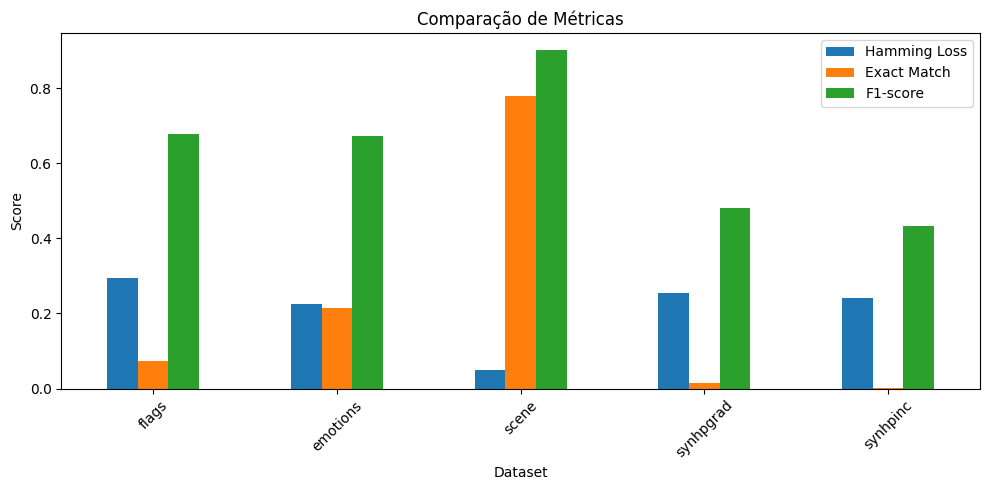

In [ ]:
metrics = [
    "Hamming Loss",
    "Exact Match",
    "F1-score"
]

df_results.plot(x="Dataset", y=metrics, kind="bar", figsize=(10,5)
)

plt.title("Comparação de Métricas")
plt.ylabel("Score")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Análise de drift com ADWIN


Dataset: flags
Número de drifts: 0
Primeiros drifts: []


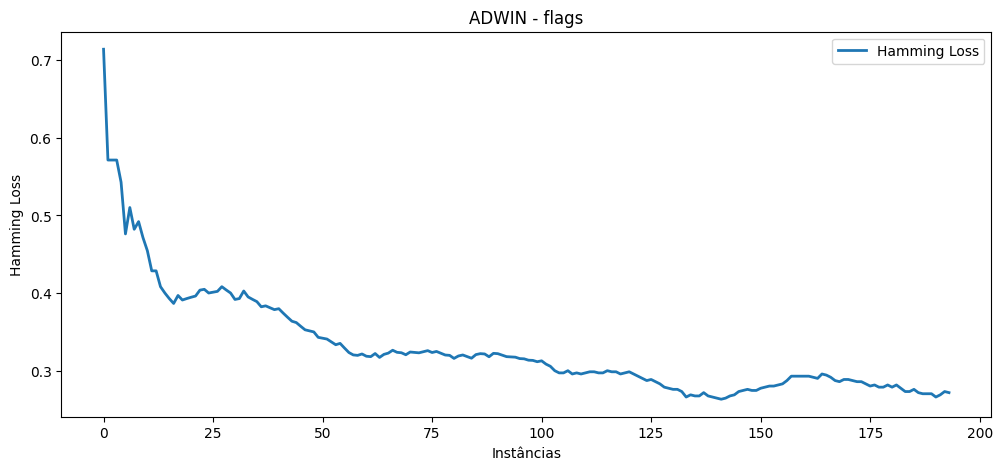


Dataset: emotions
Número de drifts: 0
Primeiros drifts: []


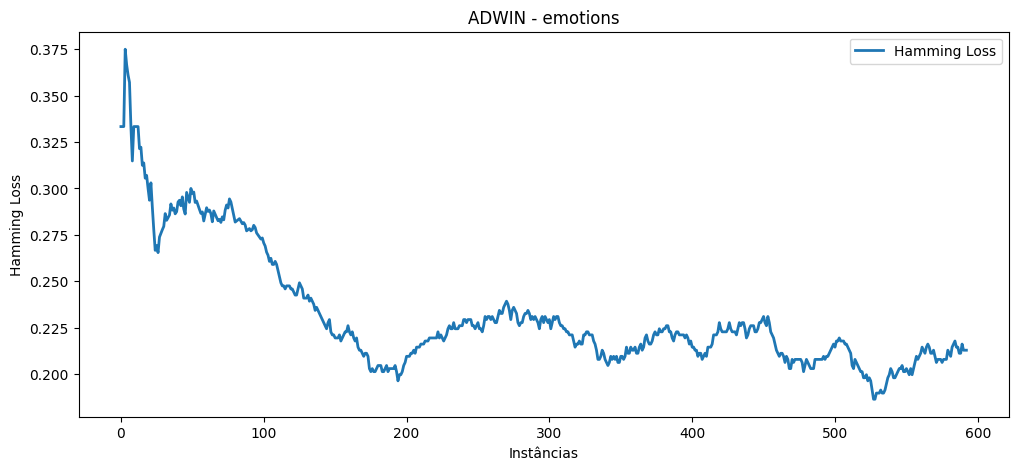


Dataset: scene
Número de drifts: 0
Primeiros drifts: []


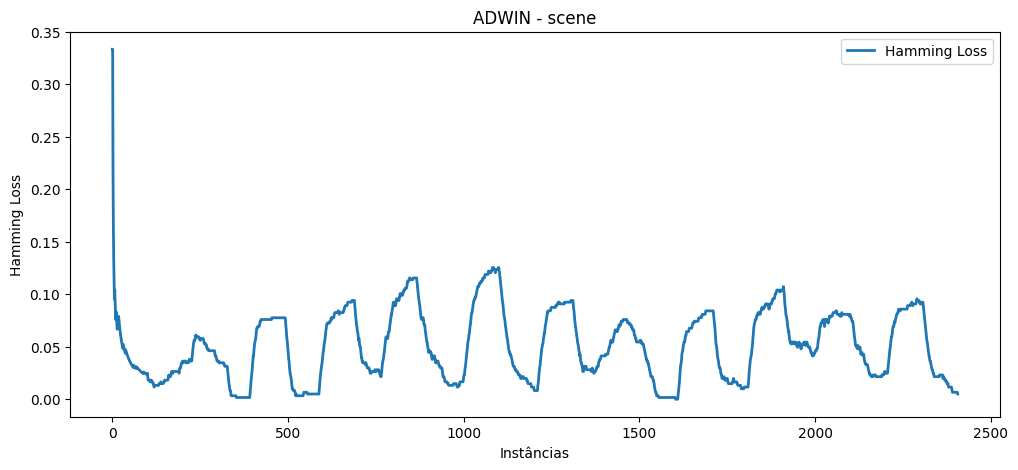


Dataset: synhpgrad
Drift detectado em 20223
Drift detectado em 24671
Drift detectado em 25183
Drift detectado em 25215
Drift detectado em 25247
Drift detectado em 25311
Drift detectado em 25375
Drift detectado em 25439
Drift detectado em 25599
Drift detectado em 27167
Número de drifts: 10
Primeiros drifts: [20223, 24671, 25183, 25215, 25247, 25311, 25375, 25439, 25599, 27167]


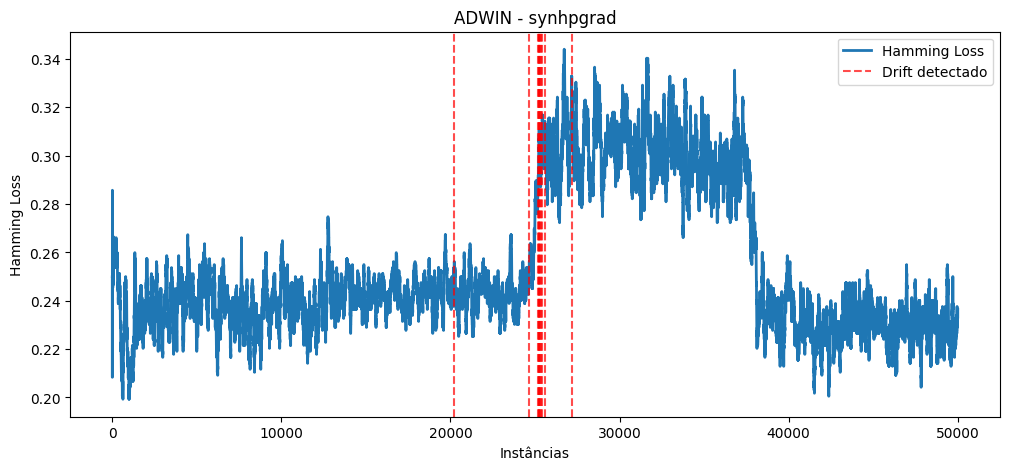


Dataset: synhpinc
Número de drifts: 0
Primeiros drifts: []


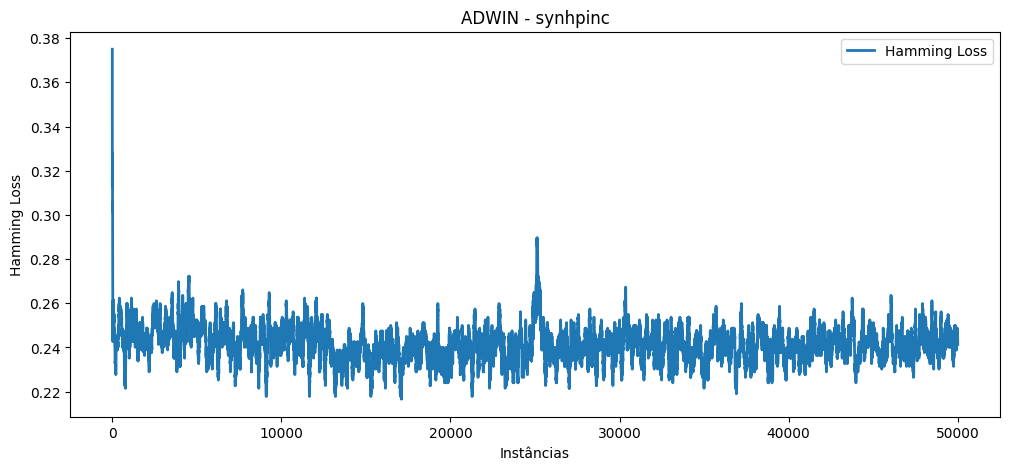

In [25]:
all_drifts = {}

for dataset_name in dataset_paths.keys():

    # roda análise
    acc_window, drift_points = drift_detection(
        dataset_name=dataset_name,
        window_size=100
    )

    # salva
    all_drifts[dataset_name] = {
        "acc_window": acc_window,
        "drift_points": drift_points
    }

    # imprime drifts
    print("Número de drifts:", len(drift_points))

    print("Primeiros drifts:", drift_points[:10])

    # gráfico
    plt.figure(figsize=(12,5))

    plt.plot(
        acc_window,
        linewidth=2,
        label="Hamming Loss"
    )

    # marca o drift no gráfico
    for j, drift in enumerate(drift_points):

        plt.axvline(
            x=drift,
            color='red',
            linestyle='--',
            alpha=0.7,
            label="Drift detectado" if j == 0 else None
        )

    plt.title(f"ADWIN - {dataset_name}")
    plt.xlabel("Instâncias")
    plt.ylabel("Hamming Loss")
    plt.legend()
    plt.show()

### Análise de consumo de memória e tempo de execução

In [26]:
rows = []

for dataset_name, results in all_results.items():

    rows.append({

        "Dataset": dataset_name,

        "Execution Time (s)": results["Execution Time (s)"],

        "Memory Usage (MB)": results["Memory Usage (MB)"]
    })

df_results = pd.DataFrame(rows)

print(df_results)

     Dataset  Execution Time (s)  Memory Usage (MB)
0      flags           11.756283         509.617188
1   emotions           75.178072        1657.265625
2      scene          509.933025         215.140625
3  synhpgrad         4197.482956        4754.285156
4   synhpinc         4440.413022           9.566406


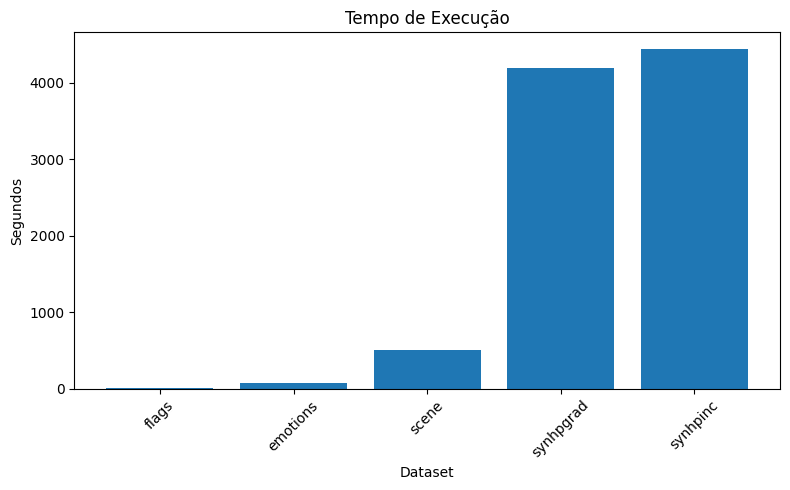

In [27]:
plt.figure(figsize=(8,5))

plt.bar(df_results["Dataset"], df_results["Execution Time (s)"]
)

plt.title("Tempo de Execução")
plt.ylabel("Segundos")
plt.xlabel("Dataset")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

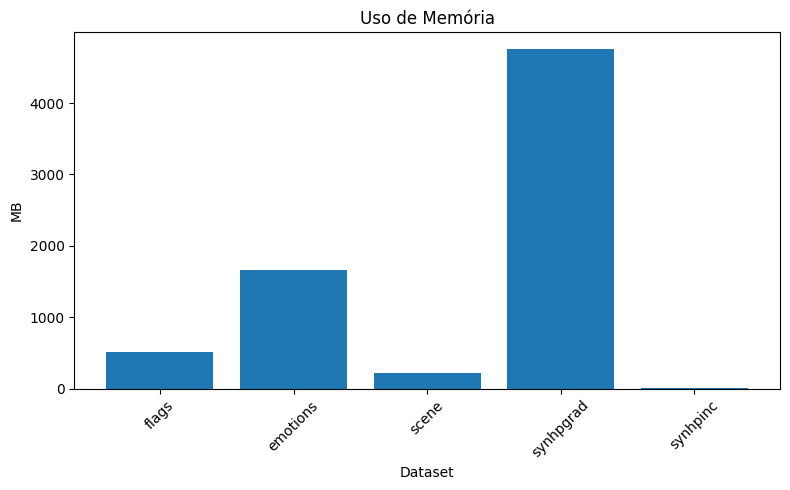

In [28]:
plt.figure(figsize=(8,5))

plt.bar(
    df_results["Dataset"],
    df_results["Memory Usage (MB)"]
)

plt.title("Uso de Memória")
plt.ylabel("MB")
plt.xlabel("Dataset")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()